Clustering Data


In [52]:
# Third-Party Library
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.sparse import load_npz
from sklearn.decomposition import TruncatedSVD

In [25]:
# Load train data
X_train = load_npz('../data/features/tfidf/X_train.npz')

df_train = pd.read_csv('../data/processed/train_metadata.csv')

print("TF-IDF Train Shape:", X_train.shape)
print("Metadata Train Shape:", df_train.shape)

print("\nAlignment valid:", X_train.shape[0] == len(df_train))

df_train.head()

TF-IDF Train Shape: (35000, 10000)
Metadata Train Shape: (35000, 2)

Alignment valid: True


,id_data,sentiment_label
0,27510,positive
1,34630,positive
2,15278,positive
3,1063,negative
4,38940,positive


In [49]:
# Load TF-IDF vectorizer

vectorizer = joblib.load(
    '../data/features/tfidf/vectorizer.pkl'
)

feature_names = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print("Feature count:", X_train.shape[1])

Vocabulary size: 10000
Feature count: 10000


In [27]:
# Finding optimal K value by applying with different K values and methods

k_values = range(2, 7)

kmeans_models = {}
kmeans_labels = {}
inertias = {}

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_train)

    kmeans_models[k] = model
    kmeans_labels[k] = labels
    inertias[k] = model.inertia_

print("K-Means finished for K =", list(k_values))

K-Means finished for K = [2, 3, 4, 5, 6]


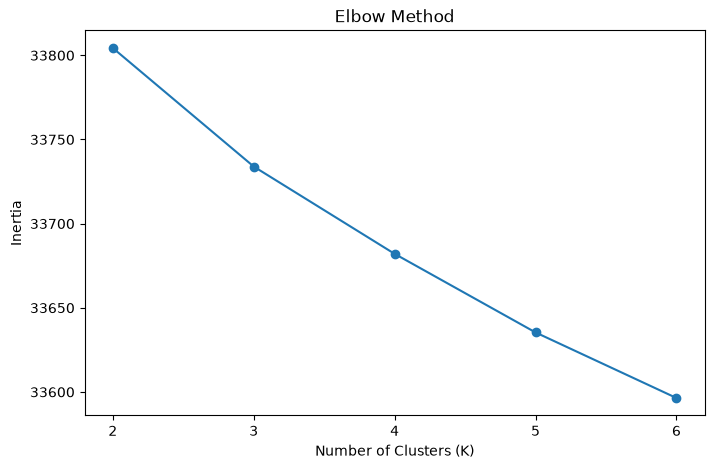

In [28]:
# Evaluating Optimal K Values using Elbow Method

plt.figure(figsize=(8, 5))
plt.plot(
    list(inertias.keys()),
    list(inertias.values()),
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(k_values))
plt.show()

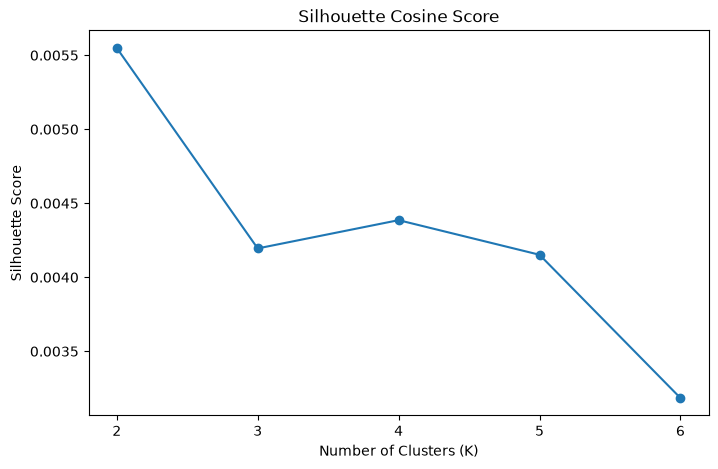

In [30]:
# Evaluating Silhouette Cosine for every K value

silhouette_cosine = {}

for k in k_values:

    labels = kmeans_labels[k]

    silhouette_cosine[k] = silhouette_score(
        X_train,
        labels,
        metric='cosine'
    )

plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_cosine.keys()),
    list(silhouette_cosine.values()),
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Cosine Score')
plt.xticks(list(k_values))
plt.show()

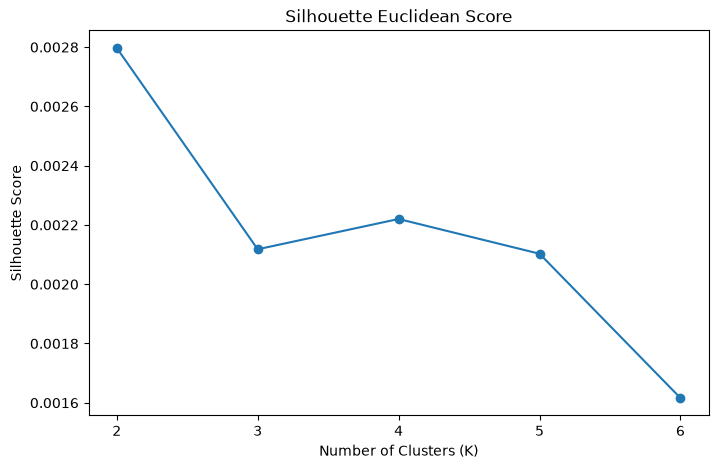

In [32]:
# Evaluating Silhouette Euclidean Score for every K value

silhouette_euclidean = {}

for k in k_values:

    labels = kmeans_labels[k]

    silhouette_euclidean[k] = silhouette_score(
        X_train,
        labels,
        metric='euclidean'
    )

plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_euclidean.keys()),
    list(silhouette_euclidean.values()),
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Euclidean Score')
plt.xticks(list(k_values))
plt.show()

In [61]:
# Initiate KMeans with the optimal number of clusters
optimal_k = 2
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Training Fitting Model
train_clusters = kmeans_model.fit_predict(X_train)

print("Fitting Model Completed.")

print("Cluster Distribution - Training:")
print(pd.Series(train_clusters).value_counts().sort_index())

Fitting Model Completed.
Cluster Distribution - Training:
0    11788
1    23212
Name: count, dtype: int64


In [36]:
# Clustering Evaluation Table

evaluation_df = pd.DataFrame({
    'K': list(k_values),
    'Inertia': [inertias[k] for k in k_values],
    'Silhouette Euclidean': [
        silhouette_euclidean[k] for k in k_values
    ],
    'Silhouette Cosine': [
        silhouette_cosine[k] for k in k_values
    ]
})

display(evaluation_df.style.format({
    'Inertia': '{:.2f}',
    'Silhouette Euclidean': '{:.6f}',
    'Silhouette Cosine': '{:.6f}'
}))


,K,Inertia,Silhouette Euclidean,Silhouette Cosine
0,2,33804.35,0.002797,0.005549
1,3,33733.93,0.002118,0.004195
2,4,33682.06,0.002220,0.004386
3,5,33635.37,0.002103,0.004152
4,6,33596.41,0.001616,0.003184


In [37]:
# Select the optimal K based on silhouette evaluation
optimal_k = 2

kmeans_model = kmeans_models[optimal_k]
train_clusters = kmeans_labels[optimal_k]

print("Optimal K:", optimal_k)
print("Centroid shape:", kmeans_model.cluster_centers_.shape)

Optimal K: 2
Centroid shape: (2, 10000)


In [44]:
# Clustered DataFrame
df_train_clustered = df_train.copy()
df_train_clustered['cluster'] = train_clusters

# Pivot table to show the distribution of sentiment labels across clusters

cluster_sentiment_pct = pd.crosstab(
    df_train_clustered['cluster'],
    df_train_clustered['sentiment_label'],
    normalize='index'
) * 100

cluster_sentiment_pct.round(2)

sentiment_label,negative,positive
cluster,,
0,62.05,37.95
1,43.88,56.12


In [46]:
# Cluster evaluation metrics

ari = adjusted_rand_score(
    df_train_clustered['sentiment_label'],
    df_train_clustered['cluster']
)

nmi = normalized_mutual_info_score(
    df_train_clustered['sentiment_label'],
    df_train_clustered['cluster']
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.0263
Normalized Mutual Information (NMI): 0.0223


Audit Cluster Results

In [50]:
# Top TF-IDF terms for each cluster

centroids = kmeans_model.cluster_centers_

top_n = 20

cluster_top_terms = {}

for cluster_id in range(optimal_k):

    top_indices = centroids[cluster_id].argsort()[-top_n:][::-1]

    cluster_top_terms[cluster_id] = pd.DataFrame({
        'term': feature_names[top_indices],
        'centroid_tfidf': centroids[cluster_id][top_indices]
    })

    print(f"\nCluster {cluster_id}")
    display(cluster_top_terms[cluster_id])


Cluster 0


,term,centroid_tfidf
0,movie,0.105949
1,movie_neg,0.037015
2,bad,0.031339
3,see,0.029492
4,like,0.026353
5,one,0.025533
6,good,0.025114
7,watch,0.024607
8,make,0.024004
9,would,0.020867



Cluster 1


,term,centroid_tfidf
0,film,0.055524
1,one,0.025123
2,see,0.020929
3,good,0.020693
4,make,0.020290
5,like,0.019518
6,show,0.019165
7,well,0.018986
8,character,0.018228
9,movie,0.018056


In [51]:
# Compare centroid differences between clusters

centroid_diff = pd.DataFrame({
    'term': feature_names,
    'cluster_0': centroids[0],
    'cluster_1': centroids[1]
})

centroid_diff['difference'] = (
    centroid_diff['cluster_0'] -
    centroid_diff['cluster_1']
)

# Terms more representative of Cluster 0
cluster_0_distinctive = centroid_diff.sort_values(
    'difference',
    ascending=False
).head(20)

# Terms more representative of Cluster 1
cluster_1_distinctive = centroid_diff.sort_values(
    'difference',
    ascending=True
).head(20)

print("Terms more distinctive to Cluster 0:")
display(cluster_0_distinctive)

print("\nTerms more distinctive to Cluster 1:")
display(cluster_1_distinctive)

Terms more distinctive to Cluster 0:


,term,cluster_0,cluster_1,difference
5756,movie,0.105949,0.018056,0.087893
5913,movie_neg,0.037015,0.005998,0.031016
785,bad,0.031339,0.011112,0.020227
798,bad movie,0.011024,0.000398,0.010626
9594,watch,0.024607,0.014396,0.010210
7820,see movie,0.011143,0.001191,0.009952
9601,watch movie,0.009738,0.000870,0.008869
8896,think,0.020745,0.012148,0.008597
7795,see,0.029492,0.020929,0.008563
5792,movie ever,0.008781,0.000457,0.008325



Terms more distinctive to Cluster 1:


,term,cluster_0,cluster_1,difference
3166,film,0.015921,0.055524,-0.039603
8015,show,0.008215,0.019165,-0.010950
3308,film_neg,0.008242,0.016064,-0.007822
2739,episode,0.001336,0.008024,-0.006688
5399,man,0.007145,0.013329,-0.006184
7907,series,0.003127,0.008803,-0.005676
9976,young,0.004219,0.009095,-0.004877
6613,performance,0.005105,0.009964,-0.004860
6722,play,0.008920,0.013743,-0.004824
9810,woman,0.004984,0.009385,-0.004401


In [54]:
# Reduce TF-IDF dimensions to 2D
svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_train_2d = svd.fit_transform(X_train)

print("Original shape :", X_train.shape)
print("Reduced shape  :", X_train_2d.shape)
print(
    "Explained variance ratio:",
    svd.explained_variance_ratio_.sum()
)

df_visualization = pd.DataFrame({
    'component_1': X_train_2d[:, 0],
    'component_2': X_train_2d[:, 1],
    'cluster': train_clusters
})

df_visualization.head()

Original shape : (35000, 10000)
Reduced shape  : (35000, 2)
Explained variance ratio: 0.00764280387764135


,component_1,component_2,cluster
0,0.072645,0.006888,1
1,0.100399,-0.041439,1
2,0.187845,0.077056,0
3,0.172321,0.143812,0
4,0.138902,-0.045273,1


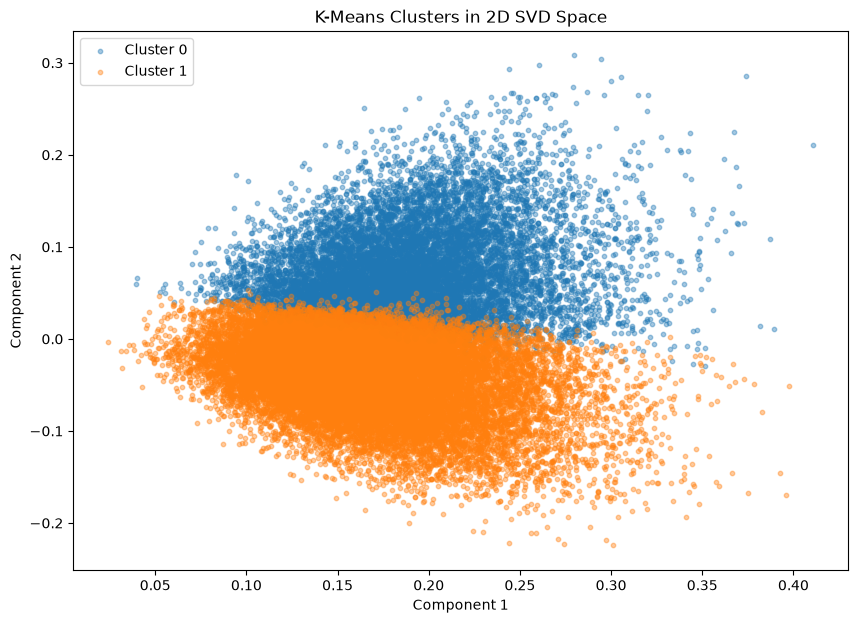

In [55]:
# Visualize Clusters
plt.figure(figsize=(10, 7))

for cluster_id in sorted(df_visualization['cluster'].unique()):

    cluster_data = df_visualization[
        df_visualization['cluster'] == cluster_id
    ]

    plt.scatter(
        cluster_data['component_1'],
        cluster_data['component_2'],
        label=f'Cluster {cluster_id}',
        alpha=0.4,
        s=10
    )

plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('K-Means Clusters in 2D SVD Space')
plt.legend()
plt.show()

Predict Cluster for Test Data

In [56]:
# Load test data
X_test = load_npz('../data/features/tfidf/X_test.npz')

df_test = pd.read_csv('../data/processed/test_metadata.csv')

print("TF-IDF Test Shape:", X_test.shape)
print("Metadata Test Shape:", df_test.shape)

print("\nAlignment valid:", X_test.shape[0] == len(df_test))

df_test.head()


TF-IDF Test Shape: (15000, 10000)
Metadata Test Shape: (15000, 2)

Alignment valid: True


,id_data,sentiment_label
0,48579,negative
1,36664,negative
2,25641,negative
3,34656,negative
4,11723,negative


In [57]:
# Predict clusters for test data
test_clusters = kmeans_model.predict(X_test)

print("Test samples :", X_test.shape[0])
print("Cluster labels:", len(test_clusters))

Test samples : 15000
Cluster labels: 15000


In [58]:
# Create clustered test DataFrame

df_test_clustered = df_test.copy()

df_test_clustered['cluster'] = test_clusters

df_test_clustered.head()

,id_data,sentiment_label,cluster
0,48579,negative,0
1,36664,negative,1
2,25641,negative,0
3,34656,negative,1
4,11723,negative,0


In [59]:
# Test cluster distribution

test_cluster_counts = (
    df_test_clustered['cluster']
    .value_counts()
    .sort_index()
)

cluster_counts = test_cluster_counts.to_numpy(dtype=float)

test_cluster_distribution = pd.DataFrame({
    'cluster': test_cluster_counts.index,
    'count': cluster_counts.astype(int),
    'percentage': (
        cluster_counts / len(test_clusters) * 100
    )
})

test_cluster_distribution

,cluster,count,percentage
0,0,4952,33.013333
1,1,10048,66.986667


In [60]:
test_cluster_sentiment_pct = pd.crosstab(
    df_test_clustered['cluster'],
    df_test_clustered['sentiment_label'],
    normalize='index'
) * 100

test_cluster_sentiment_pct.round(2)

sentiment_label,negative,positive
cluster,,
0,62.22,37.78
1,43.98,56.02


In [62]:
ari_test = adjusted_rand_score(
    df_test_clustered['sentiment_label'],
    df_test_clustered['cluster']
)

nmi_test = normalized_mutual_info_score(
    df_test_clustered['sentiment_label'],
    df_test_clustered['cluster']
)

print(f"Test ARI: {ari_test:.4f}")
print(f"Test NMI: {nmi_test:.4f}")

Test ARI: 0.0260
Test NMI: 0.0223


Summary of Cluster Distribution

In [64]:
# Compare cluster distribution between train and test

train_distribution = (
    df_train_clustered['cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

test_distribution = (
    df_test_clustered['cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_distribution_comparison = pd.DataFrame({
    'Train (%)': train_distribution,
    'Test (%)': test_distribution
})

cluster_distribution_comparison.round(2)

,Train (%),Test (%)
cluster,,
0,33.68,33.01
1,66.32,66.99


In [66]:
# Final Clustering Evaluation

final_clustering_evaluation = pd.DataFrame({
    'Metric': [
        'Number of Clusters (K)',
        'Train Samples',
        'Test Samples',
        'Train Cluster 0 (%)',
        'Train Cluster 1 (%)',
        'Test Cluster 0 (%)',
        'Test Cluster 1 (%)',
        'Silhouette Euclidean',
        'Silhouette Cosine',
        'Train ARI',
        'Test ARI',
        'Train NMI',
        'Test NMI'
    ],
    'Value': [
        optimal_k,
        X_train.shape[0],
        X_test.shape[0],
        train_distribution.get(0, 0),
        train_distribution.get(1, 0),
        test_distribution.get(0, 0),
        test_distribution.get(1, 0),
        silhouette_euclidean[optimal_k],
        silhouette_cosine[optimal_k],
        ari,
        ari_test,
        nmi,
        nmi_test
    ]
})

display(
    final_clustering_evaluation.style.format({
        'Value': '{:.4f}'
    })
)

,Metric,Value
0,Number of Clusters (K),2.0000
1,Train Samples,35000.0000
2,Test Samples,15000.0000
3,Train Cluster 0 (%),33.6800
4,Train Cluster 1 (%),66.3200
5,Test Cluster 0 (%),33.0133
6,Test Cluster 1 (%),66.9867
7,Silhouette Euclidean,0.0028
8,Silhouette Cosine,0.0055
9,Train ARI,0.0263


In [67]:
# Sentiment distribution by cluster

final_sentiment_distribution = pd.DataFrame({
    'Train Negative (%)': cluster_sentiment_pct['negative'],
    'Train Positive (%)': cluster_sentiment_pct['positive'],
    'Test Negative (%)': test_cluster_sentiment_pct['negative'],
    'Test Positive (%)': test_cluster_sentiment_pct['positive']
}).round(2)

final_sentiment_distribution

,Train Negative (%),Train Positive (%),Test Negative (%),Test Positive (%)
cluster,,,,
0,62.05,37.95,62.22,37.78
1,43.88,56.12,43.98,56.02
